In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from math import pi

warnings.filterwarnings('ignore')

# Set Seaborn style for better-looking plots and larger fonts
sns.set_style('whitegrid')
sns.set_context('talk')  # Increases font sizes for readability
sns.set_palette("husl")

In [2]:
# Read the CSV file
df = pd.read_csv('scheduling_data.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Clean and prepare the data
print("\nCleaning data...")
# Remove extra quotes from Assigned Nodes column
df['Assigned Nodes'] = df['Assigned Nodes'].astype(str).str.replace('"', '')

Data loaded successfully!
Shape: (87, 16)

First few rows:
  Scheduling Algorithm     Type  Process ID  Arrival Time  Burst Time  \
0         ContextAware  Process         2.0           0.0        29.0   
1         ContextAware  Process         1.0          24.0        58.0   
2         ContextAware  Process         7.0          47.0        55.0   
3         ContextAware  Process         5.0          48.0        36.0   
4         ContextAware  Process         4.0          74.0        35.0   

   Start Time  Completion Time  Waiting Time  Turnaround Time Assigned Nodes  \
0         0.0             29.0           0.0             29.0            "2"   
1        24.0             82.0           0.0             58.0            "3"   
2        47.0            102.0           0.0             55.0            "2"   
3        48.0             84.0           0.0             36.0            "1"   
4        74.0            109.0           0.0             35.0            "4"   

      Status Metric V

In [3]:
# Extract summary data for each algorithm
algorithms = df['Scheduling Algorithm'].unique()
print(f"Algorithms found: {algorithms}")

Algorithms found: ['ContextAware' 'FCFS' 'SJF']


In [4]:
# Create summary statistics dataframe
summary_stats = []
for algo in algorithms:
    algo_data = df[df['Scheduling Algorithm'] == algo]
    summary_data = algo_data[algo_data['Type'] == 'Summary']
    
    if not summary_data.empty:
        stats = {'Algorithm': algo}
        for _, row in summary_data.iterrows():
            if pd.notna(row['Metric']) and pd.notna(row['Value']):
                metric = row['Metric']
                value = row['Value']
                if isinstance(value, str):
                    if 'calculations' in value:
                        value = float(value.split()[0])
                    else:
                        try:
                            value = float(value)
                        except:
                            pass
                stats[metric] = value
        summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
print("\nSummary statistics extracted:")
print(summary_df)


Summary statistics extracted:
       Algorithm Metric  Total Processes  Scheduled Processes  \
0  Context-Aware  Value              8.0                  8.0   
1           FCFS  Value              8.0                  8.0   
2            SJF  Value              8.0                  8.0   

   Failed Processes  Success Rate  Total Execution Time  Average Waiting Time  \
0               0.0         100.0                 141.0                 0.375   
1               0.0         100.0                 202.0                36.875   
2               0.0         100.0                 376.0               105.500   

   Average Turnaround Time  Throughput  CPU Utilization  Memory Utilization  \
0                   41.750    0.056738         13.18950             63.5014   
1                   78.250    0.039604          9.20652             44.3252   
2                  146.875    0.021277          4.94606             23.8130   

   Bandwidth Utilization  Scheduling Overhead  Process Score Calcu

In [5]:
# Calculate additional metrics to replace Success Rate
summary_df['Resource Efficiency'] = (summary_df['CPU Utilization'] + 
                                   summary_df['Memory Utilization'] + 
                                   summary_df['Bandwidth Utilization']) / 3

summary_df['Scheduling Efficiency'] = summary_df['Total Processes'] / summary_df['Scheduling Overhead']

print("\nCalculated additional metrics:")
print(f"Shape: {summary_df.shape}")
print("\nFinal Summary DataFrame:")
print(summary_df)


Calculated additional metrics:
Shape: (3, 22)

Final Summary DataFrame:
       Algorithm Metric  Total Processes  Scheduled Processes  \
0  Context-Aware  Value              8.0                  8.0   
1           FCFS  Value              8.0                  8.0   
2            SJF  Value              8.0                  8.0   

   Failed Processes  Success Rate  Total Execution Time  Average Waiting Time  \
0               0.0         100.0                 141.0                 0.375   
1               0.0         100.0                 202.0                36.875   
2               0.0         100.0                 376.0               105.500   

   Average Turnaround Time  Throughput  ...  Bandwidth Utilization  \
0                   41.750    0.056738  ...                7.71517   
1                   78.250    0.039604  ...                5.38534   
2                  146.875    0.021277  ...                2.89319   

   Scheduling Overhead  Process Score Calculations  Node Sco

In [6]:
# Define a consistent color palette for algorithms
algo_palette = sns.color_palette('husl', n_colors=len(algorithms))

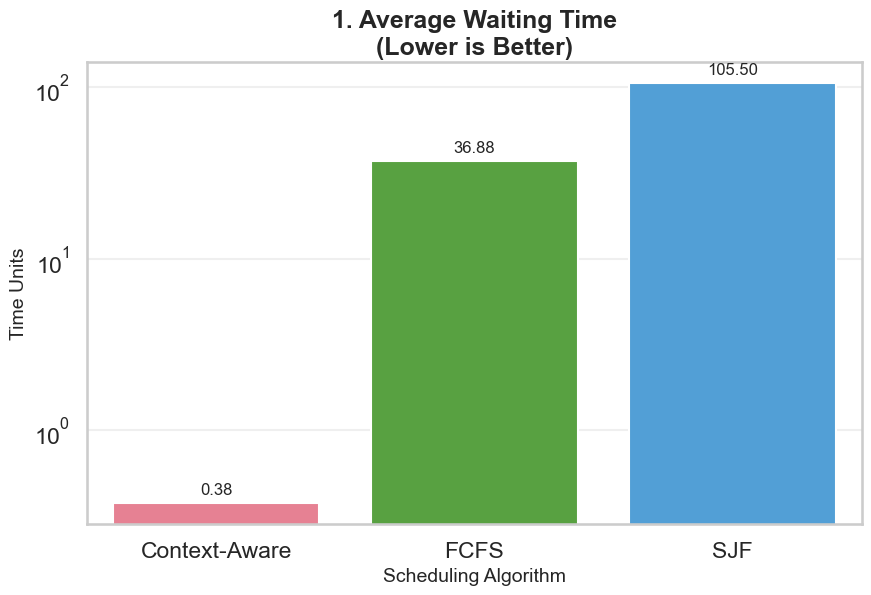

In [19]:
# **1. Average Waiting Time (Lower is Better)**
if 'Average Waiting Time' in summary_df.columns:
    plt.figure(figsize=(10, 6))  # Increased figure size for clarity
    ax = sns.barplot(x='Algorithm', y='Average Waiting Time', data=summary_df, palette=algo_palette)
    plt.title('1. Average Waiting Time\n(Lower is Better)', fontsize=18, fontweight='bold')
    plt.yscale('log')  # Log scale for better visibility
    plt.ylabel('Time Units', fontsize=14)
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)
    plt.show()

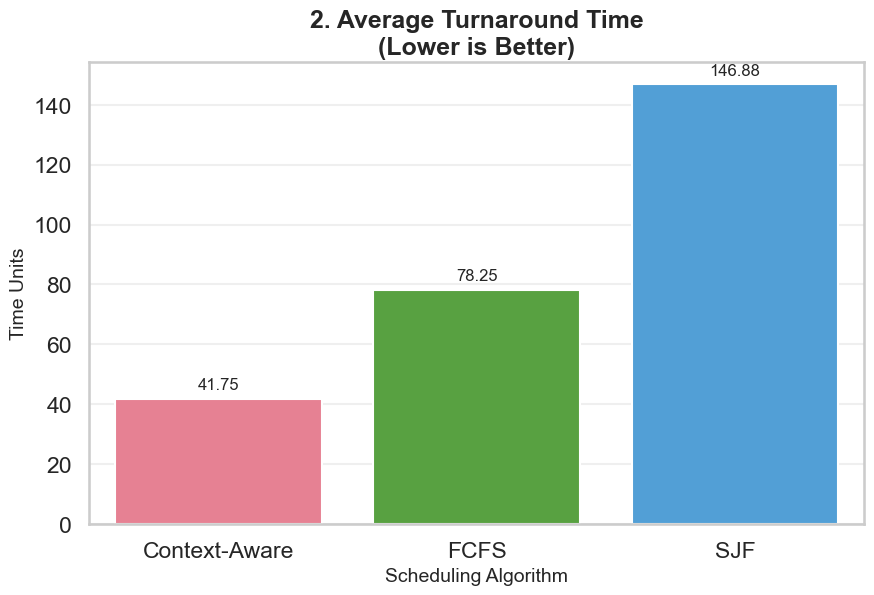

In [8]:
# **2. Average Turnaround Time (Lower is Better)**
if 'Average Turnaround Time' in summary_df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Algorithm', y='Average Turnaround Time', data=summary_df, palette=algo_palette)
    plt.title('2. Average Turnaround Time\n(Lower is Better)', fontsize=18, fontweight='bold')
    plt.ylabel('Time Units', fontsize=14)
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)
    plt.show()

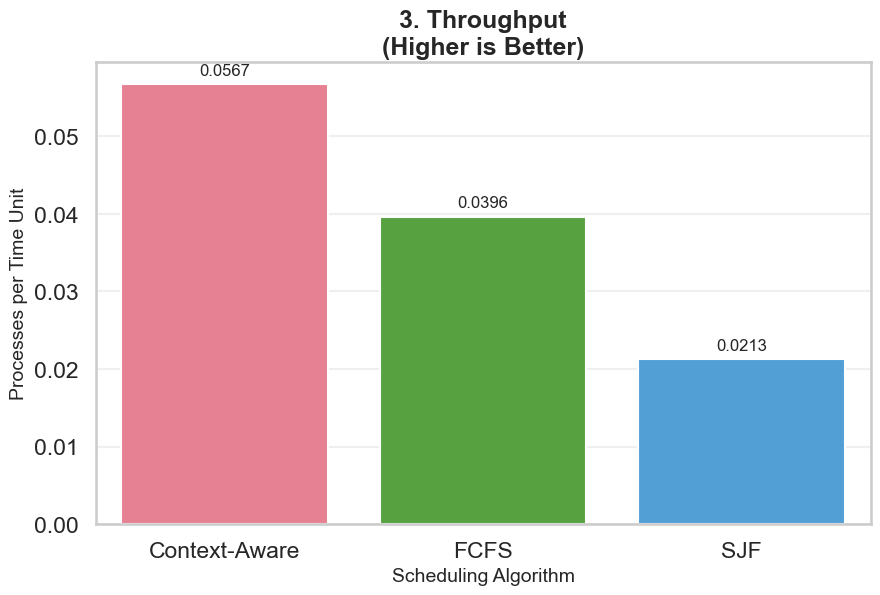

In [9]:
# **3. Throughput (Higher is Better)**
if 'Throughput' in summary_df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Algorithm', y='Throughput', data=summary_df, palette=algo_palette)
    plt.title('3. Throughput\n(Higher is Better)', fontsize=18, fontweight='bold')
    plt.ylabel('Processes per Time Unit', fontsize=14)
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)
    plt.show()

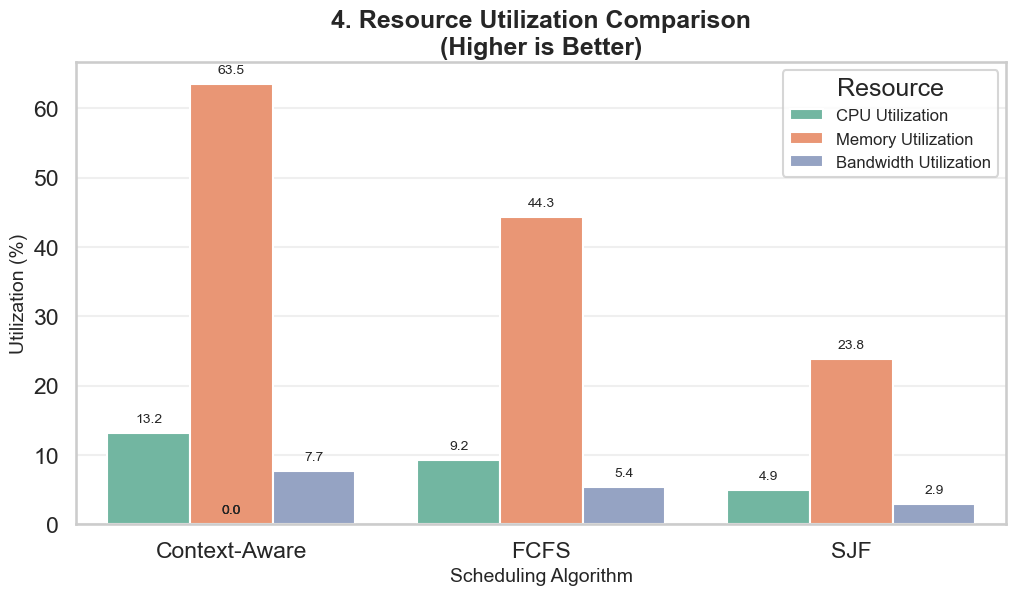

In [10]:
# **4. Resource Utilization Comparison (Combined)**
utilization_metrics = [metric for metric in ['CPU Utilization', 'Memory Utilization', 'Bandwidth Utilization'] 
                       if metric in summary_df.columns]
if utilization_metrics:
    utilization_melted = summary_df.melt(id_vars='Algorithm', value_vars=utilization_metrics, 
                                         var_name='Resource', value_name='Utilization')
    plt.figure(figsize=(12, 6))
    resource_palette = sns.color_palette('Set2', n_colors=len(utilization_metrics))
    ax = sns.barplot(x='Algorithm', y='Utilization', hue='Resource', data=utilization_melted, palette=resource_palette)
    plt.title('4. Resource Utilization Comparison\n(Higher is Better)', fontsize=18, fontweight='bold')
    plt.ylabel('Utilization (%)', fontsize=14)
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.xticks(rotation=0)
    plt.legend(title='Resource', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):  # Only annotate non-NaN values
            ax.annotate(f'{height:.1f}', (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)
    plt.show()

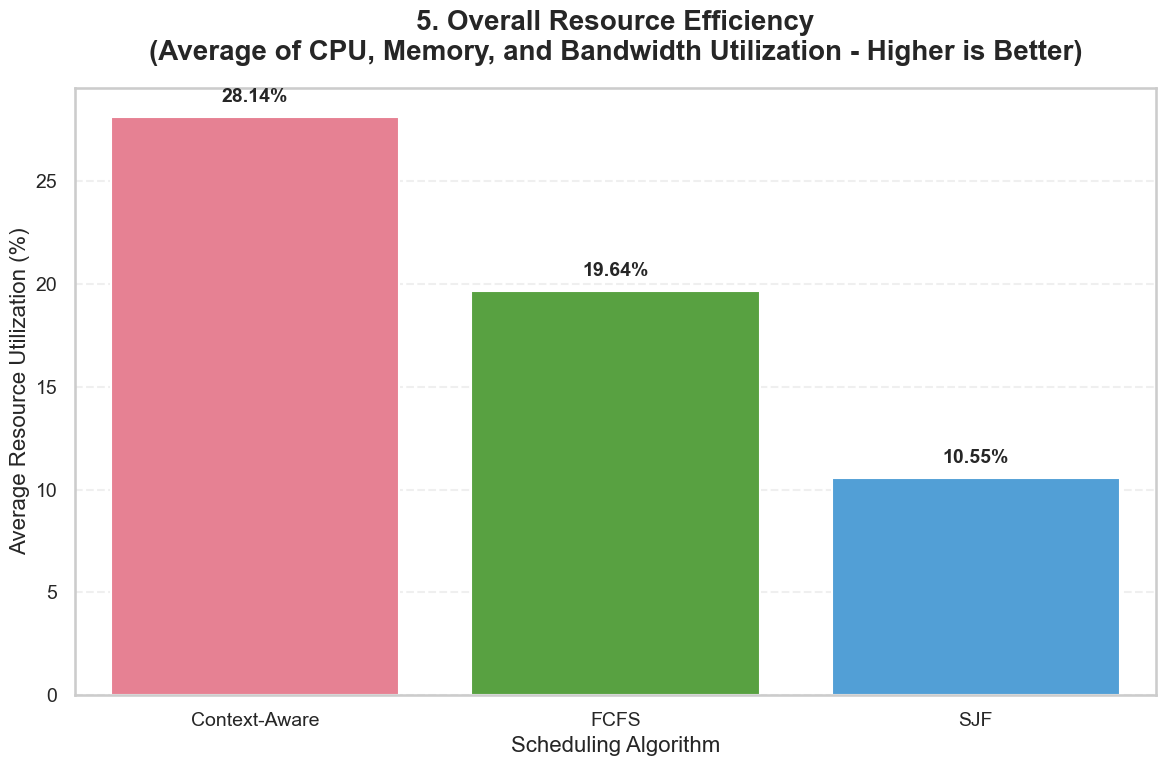

In [11]:
# **5. Resource Efficiency (Higher is Better)**
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Algorithm', y='Resource Efficiency', data=summary_df, palette=algo_palette)
plt.title('5. Overall Resource Efficiency\n(Average of CPU, Memory, and Bandwidth Utilization - Higher is Better)', 
          fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Average Resource Utilization (%)', fontsize=16)
plt.xlabel('Scheduling Algorithm', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value annotations
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', xytext=(0, 8), 
                textcoords='offset points', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

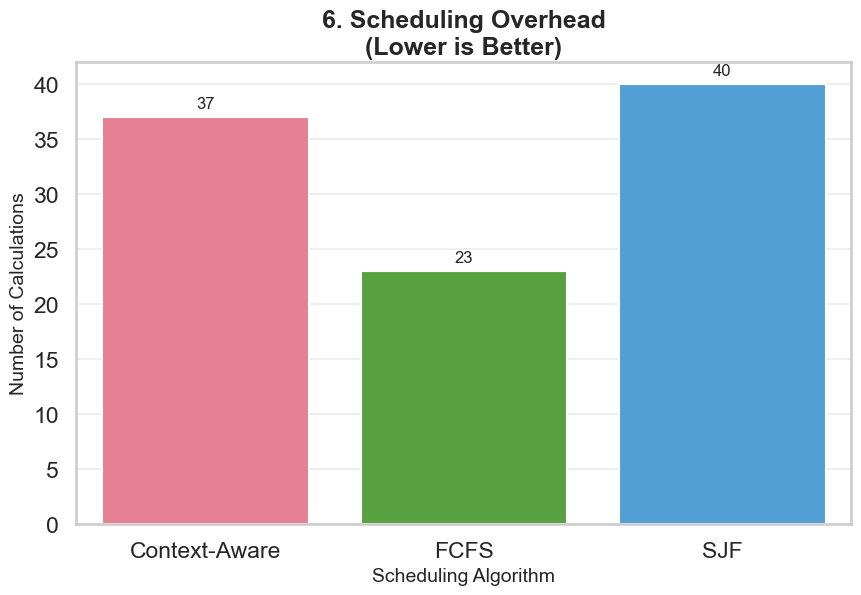

In [12]:
# **6. Scheduling Overhead (Lower is Better)**
if 'Scheduling Overhead' in summary_df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Algorithm', y='Scheduling Overhead', data=summary_df, palette=algo_palette)
    plt.title('6. Scheduling Overhead\n(Lower is Better)', fontsize=18, fontweight='bold')
    plt.ylabel('Number of Calculations', fontsize=14)
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)
    plt.show()

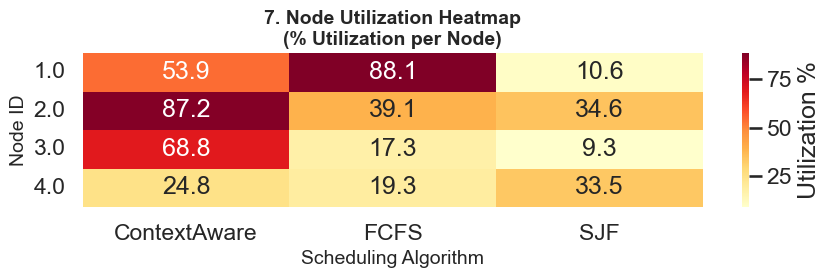

In [13]:
# **7. Node Utilization Analysis**
node_data = df[df['Type'] == 'Node Utilization'].copy()
if not node_data.empty:
    node_pivot = node_data.pivot_table(index='Node ID', columns='Scheduling Algorithm', 
                                       values='Utilization Percent', aggfunc='first')
    plt.figure(figsize=(10, len(node_pivot) * 0.5))  # Dynamic size based on nodes
    sns.heatmap(node_pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Utilization %'})
    plt.title('7. Node Utilization Heatmap\n(% Utilization per Node)', fontsize=14, fontweight='bold')
    plt.xlabel('Scheduling Algorithm', fontsize=14)
    plt.ylabel('Node ID', fontsize=14)
    plt.yticks(rotation=0)
    plt.show()

In [14]:
# **Detailed Summary Table**
print("\n" + "="*80)
print("DETAILED PERFORMANCE COMPARISON TABLE")
print("="*80)
key_metrics = ['Algorithm', 'Average Waiting Time', 'Average Turnaround Time', 
               'Throughput', 'CPU Utilization', 'Success Rate', 'Scheduling Overhead']
available_key_metrics = [m for m in key_metrics if m in summary_df.columns]
comparison_display = summary_df[available_key_metrics]
print(comparison_display.to_string(index=False, float_format='%.3f'))

# **Performance Ranking Analysis**
print("\n" + "="*80)
print("PERFORMANCE RANKING ANALYSIS")
print("="*80)
rankings = {algo: {'scores': [], 'total_score': 0} for algo in summary_df['Algorithm']}
metrics_info = {
    'Average Waiting Time': {'direction': 'lower', 'weight': 1},
    'Average Turnaround Time': {'direction': 'lower', 'weight': 1},
    'Throughput': {'direction': 'higher', 'weight': 1},
    'CPU Utilization': {'direction': 'higher', 'weight': 1},
    'Success Rate': {'direction': 'higher', 'weight': 1},
    'Scheduling Overhead': {'direction': 'lower', 'weight': 0.5}
}
for metric, info in metrics_info.items():
    if metric in summary_df.columns:
        values = summary_df[metric].values
        if info['direction'] == 'lower':
            scores = [(max(values) - v) / (max(values) - min(values)) if max(values) != min(values) else 1 
                      for v in values]
        else:
            scores = [(v - min(values)) / (max(values) - min(values)) if max(values) != min(values) else 1 
                      for v in values]
        for i, algo in enumerate(summary_df['Algorithm']):
            rankings[algo]['scores'].append(scores[i] * info['weight'])
            rankings[algo]['total_score'] += scores[i] * info['weight']
sorted_rankings = sorted(rankings.items(), key=lambda x: x[1]['total_score'], reverse=True)
print("Ranking (Higher score is better):")
for i, (algo, data) in enumerate(sorted_rankings, 1):
    print(f"{i}. {algo}: {data['total_score']:.3f}")


DETAILED PERFORMANCE COMPARISON TABLE
    Algorithm  Average Waiting Time  Average Turnaround Time  Throughput  CPU Utilization  Success Rate  Scheduling Overhead
Context-Aware                 0.375                   41.750       0.057           13.190       100.000               37.000
         FCFS                36.875                   78.250       0.040            9.207       100.000               23.000
          SJF               105.500                  146.875       0.021            4.946       100.000               40.000

PERFORMANCE RANKING ANALYSIS
Ranking (Higher score is better):
1. Context-Aware: 5.088
2. FCFS: 3.839
3. SJF: 1.000


In [15]:
# **Key Insights**
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
insights = []
for metric, info in metrics_info.items():
    if metric in summary_df.columns:
        if info['direction'] == 'lower':
            best_idx, worst_idx = summary_df[metric].idxmin(), summary_df[metric].idxmax()
        else:
            best_idx, worst_idx = summary_df[metric].idxmax(), summary_df[metric].idxmin()
        best_algo, worst_algo = summary_df.loc[best_idx, 'Algorithm'], summary_df.loc[worst_idx, 'Algorithm']
        best_val, worst_val = summary_df.loc[best_idx, metric], summary_df.loc[worst_idx, metric]
        insights.append(f"• {metric}: Best = {best_algo} ({best_val:.3f}), Worst = {worst_algo} ({worst_val:.3f})")
for insight in insights:
    print(insight)
print(f"\nOverall Best Performer: {sorted_rankings[0][0]}")
print(f"Overall Score: {sorted_rankings[0][1]['total_score']:.3f}")


KEY INSIGHTS
• Average Waiting Time: Best = Context-Aware (0.375), Worst = SJF (105.500)
• Average Turnaround Time: Best = Context-Aware (41.750), Worst = SJF (146.875)
• Throughput: Best = Context-Aware (0.057), Worst = SJF (0.021)
• CPU Utilization: Best = Context-Aware (13.190), Worst = SJF (4.946)
• Success Rate: Best = Context-Aware (100.000), Worst = Context-Aware (100.000)
• Scheduling Overhead: Best = FCFS (23.000), Worst = SJF (40.000)

Overall Best Performer: Context-Aware
Overall Score: 5.088


<Figure size 1600x1000 with 0 Axes>

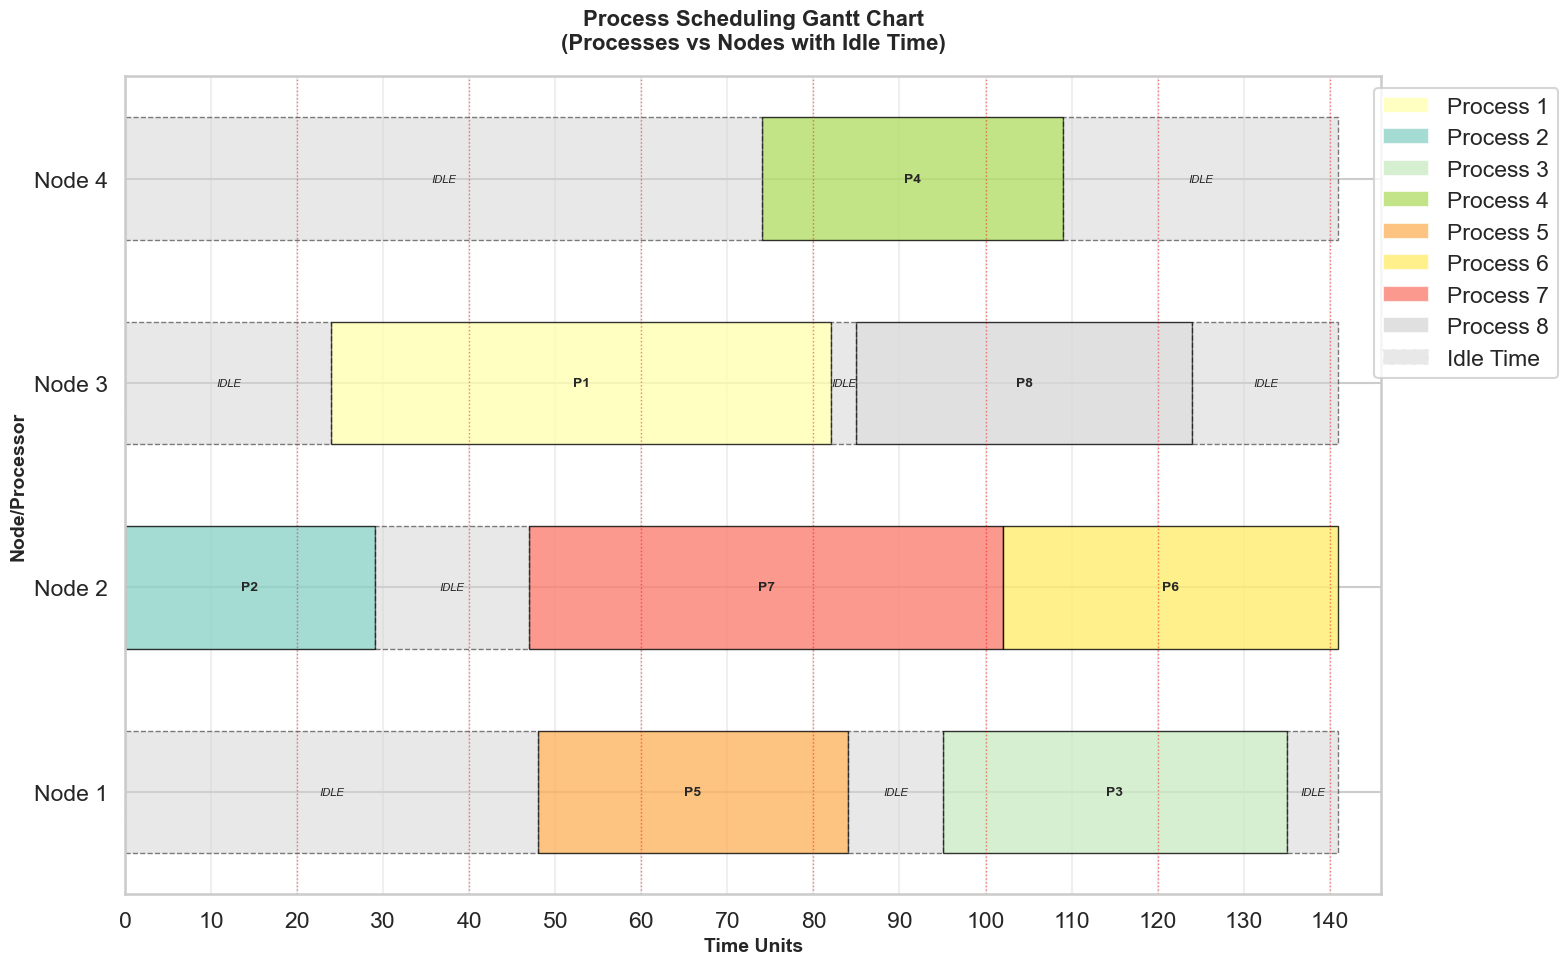

Process Scheduling Summary:
Process 2: Node 2, Time 0-29 (Duration: 29)
Process 1: Node 3, Time 24-82 (Duration: 58)
Process 7: Node 2, Time 47-102 (Duration: 55)
Process 5: Node 1, Time 48-84 (Duration: 36)
Process 4: Node 4, Time 74-109 (Duration: 35)
Process 8: Node 3, Time 85-124 (Duration: 39)
Process 3: Node 1, Time 95-135 (Duration: 40)
Process 6: Node 2, Time 102-141 (Duration: 39)

Total execution time: 141 time units
Number of nodes used: 4

Node Utilization:
------------------------------
Node 1: 53.9% (76/141 time units)
Node 2: 87.2% (123/141 time units)
Node 3: 68.8% (97/141 time units)
Node 4: 24.8% (35/141 time units)


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the data
data = {
    'Process_ID': [2, 1, 7, 5, 4, 8, 3, 6],
    'Arrival_Time': [0, 24, 47, 48, 74, 85, 95, 99],
    'Burst_Time': [29, 58, 55, 36, 35, 39, 40, 39],
    'Start_Time': [0, 24, 47, 48, 74, 85, 95, 102],
    'Completion_Time': [29, 82, 102, 84, 109, 124, 135, 141],
    'Waiting_Time': [0, 0, 0, 0, 0, 0, 0, 3],
    'Turnaround_Time': [29, 58, 55, 36, 35, 39, 40, 42],
    'Assigned_Nodes': [2, 3, 2, 1, 4, 3, 1, 2],
    'Status': ['Scheduled'] * 8
}

df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# Define colors for each process
colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
process_colors = {row['Process_ID']: colors[i] for i, row in df.iterrows()}

# Get unique nodes and sort them
nodes = sorted(df['Assigned_Nodes'].unique())
max_time = df['Completion_Time'].max()

# Create the gantt chart
fig, ax = plt.subplots(figsize=(16, 10))

# Track the last completion time for each node to identify idle periods
node_timeline = {node: [] for node in nodes}

# Add process bars for each node
for _, row in df.iterrows():
    node = row['Assigned_Nodes']
    start = row['Start_Time']
    duration = row['Burst_Time']
    process_id = row['Process_ID']
    
    # Add the process execution bar
    ax.barh(node, duration, left=start, height=0.6, 
            color=process_colors[process_id], alpha=0.8, 
            edgecolor='black', linewidth=1)
    
    # Add process ID label on the bar
    ax.text(start + duration/2, node, f'P{process_id}', 
            ha='center', va='center', fontweight='bold', fontsize=10)
    
    # Track timeline for idle time calculation
    node_timeline[node].append((start, start + duration))

# Add idle time periods
for node in nodes:
    # Sort timeline events for this node
    node_timeline[node].sort()
    
    # Check for idle time at the beginning
    if node_timeline[node] and node_timeline[node][0][0] > 0:
        idle_duration = node_timeline[node][0][0]
        ax.barh(node, idle_duration, left=0, height=0.6, 
                color='lightgray', alpha=0.5, edgecolor='black', 
                linewidth=1, linestyle='--')
        ax.text(idle_duration/2, node, 'IDLE', 
                ha='center', va='center', fontsize=8, style='italic')
    
    # Check for idle time between processes
    for i in range(len(node_timeline[node]) - 1):
        current_end = node_timeline[node][i][1]
        next_start = node_timeline[node][i + 1][0]
        
        if next_start > current_end:
            idle_duration = next_start - current_end
            ax.barh(node, idle_duration, left=current_end, height=0.6, 
                    color='lightgray', alpha=0.5, edgecolor='black', 
                    linewidth=1, linestyle='--')
            ax.text(current_end + idle_duration/2, node, 'IDLE', 
                    ha='center', va='center', fontsize=8, style='italic')
    
    # Check for idle time at the end (if node finishes before max_time)
    if node_timeline[node]:
        last_completion = max(end for start, end in node_timeline[node])
        if last_completion < max_time:
            idle_duration = max_time - last_completion
            ax.barh(node, idle_duration, left=last_completion, height=0.6, 
                    color='lightgray', alpha=0.5, edgecolor='black', 
                    linewidth=1, linestyle='--')
            ax.text(last_completion + idle_duration/2, node, 'IDLE', 
                    ha='center', va='center', fontsize=8, style='italic')

# Customize the plot
ax.set_xlabel('Time Units', fontsize=14, fontweight='bold')
ax.set_ylabel('Node/Processor', fontsize=14, fontweight='bold')
ax.set_title('Process Scheduling Gantt Chart\n(Processes vs Nodes with Idle Time)', 
             fontsize=16, fontweight='bold', pad=20)

# Set y-axis
ax.set_yticks(nodes)
ax.set_yticklabels([f'Node {node}' for node in nodes])
ax.set_ylim(0.5, max(nodes) + 0.5)

# Set x-axis
ax.set_xlim(0, max_time + 5)
ax.set_xticks(range(0, max_time + 1, 10))

# Add grid
ax.grid(True, axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Create legend
legend_elements = []
for process_id in sorted(df['Process_ID'].unique()):
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=process_colors[process_id], 
                                       alpha=0.8, label=f'Process {process_id}'))
legend_elements.append(plt.Rectangle((0,0),1,1, facecolor='lightgray', alpha=0.5, 
                                   linestyle='--', label='Idle Time'))

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

# Add timeline markers
for i in range(0, max_time + 1, 20):
    ax.axvline(x=i, color='red', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

# Print process scheduling summary
print("Process Scheduling Summary:")
print("=" * 50)
df_sorted = df.sort_values('Start_Time')
for _, row in df_sorted.iterrows():
    print(f"Process {row['Process_ID']}: Node {row['Assigned_Nodes']}, "
          f"Time {row['Start_Time']}-{row['Completion_Time']} "
          f"(Duration: {row['Burst_Time']})")

print(f"\nTotal execution time: {max_time} time units")
print(f"Number of nodes used: {len(nodes)}")

# Calculate and display utilization for each node
print("\nNode Utilization:")
print("-" * 30)
for node in sorted(nodes):
    node_processes = df[df['Assigned_Nodes'] == node]
    total_busy_time = node_processes['Burst_Time'].sum()
    utilization = (total_busy_time / max_time) * 100
    print(f"Node {node}: {utilization:.1f}% ({total_busy_time}/{max_time} time units)")